# 07 — LSTM with MIDAS-Imputed Macro Features (Weekly)

Implements the **MIDAS-as-imputer** hybrid (cf. supervisor's suggestion: use one model to
extract a high-frequency representation of low-frequency variables, then feed it into
another model that does the forecasting).

**Idea.** Monthly macro variables (CPI, Fed Funds, industrial production, real rates) are
sampled at $1/4$ the LSTM's native weekly frequency. Naïve options:

1. Forward-fill monthly values across the 4 weeks until the next release → flat steps,
   introduces look-ahead bias on release weeks.
2. Skip macro entirely → throw away information.

**This notebook** takes a third route:

> Fit a MIDAS regression on **train only**, with weekly silver as target and 3-monthly
> lags of each macro variable, restricted by **Beta polynomial weights**. The fitted
> weights $\hat w_v(\theta_v)$ give one weekly composite per macro variable:
> $$ m_{v,t} = \sum_{k=1}^{K} \hat w_{v,k}\,z_{v,t-k} $$
> These four composites are added to the LSTM's feature matrix alongside EXOG.

Each model does what it's designed for:
- **MIDAS** = principled frequency reduction (Beta weights, NLS-fit on train only)
- **LSTM** = nonlinear sequence dynamics on the resulting weekly inputs

**Alignment with thesis conventions** (`CLAUDE.md`):
- Same `train/val/test.csv` and W-FRI aggregation as `04`–`06b`
- EXOG = silver_return + 6 cross-asset weekly returns (auto-lagged inside LSTM sequence)
- Hyperparameter grid tuned once on `LSTM-EXOG` (no MIDAS), reused across variants
- Naïve $y_{t-1}$ baseline, DM tests vs `LSTM-EXOG`, period breakdown, 2026 zoom

**Variants:**
| Variant | EXOG | MIDAS-macro composites | Sentiment |
|---|---|---|---|
| `LSTM-EXOG` | ✓ | | |
| `LSTM-EXOG-MACROMIDAS` | ✓ | ✓ | |
| `LSTM-EXOG-MACROMIDAS-SENTIMENT` | ✓ | ✓ | Reddit + News |

Baseline for DM = `LSTM-EXOG` (matching `06_lstm.ipynb`).

**Honest caveat.** Beta weights are fit on train using silver as target, so the composites
are "informed by silver" — *not* leakage strictly (weights are fixed before val/test) but
worth noting: the composites are purpose-built for silver prediction, which is exactly the
intent of the hybrid.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import minimize
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from itertools import product
import warnings, os, sys
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Device: mps


In [2]:
# Hyperparameters mirror 06_lstm.ipynb defaults; §3 tunes them
SEQ_LEN  = 20
HORIZON  = 1
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.2
EPOCHS   = 150
LR       = 1e-3
PATIENCE = 15
BATCH    = 16

TARGET = 'silver_return'


## 2. Load + weekly aggregation (W-FRI)

Same split as every other weekly notebook: train ≤ 2021-12-31, val = 2022, test ≥ 2023.


In [3]:
train_d = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val_d   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test_d  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

EXOG = ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']
FEAT_COLS = [TARGET] + [c for c in EXOG if c in train_d.columns]

def to_weekly(df):
    return df[FEAT_COLS].resample('W-FRI').sum().dropna()

train = to_weekly(train_d)
val   = to_weekly(val_d)
test  = to_weekly(test_d)

# Optional sentiment merge (forward-fill into weekly mean, same as 06)
sent_path = '../../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sent[['reddit_sentiment','news_sentiment']].resample('W-FRI').mean()
    for df in [train, val, test]:
        for col in ['reddit_sentiment','news_sentiment']:
            df[col] = sent_w[col].reindex(df.index).ffill().fillna(0)
    print('Sentiment merged.')
else:
    for df in [train, val, test]:
        df['reddit_sentiment'] = 0.0
        df['news_sentiment']   = 0.0

print(f'Train weeks: {len(train)}  Val weeks: {len(val)}  Test weeks: {len(test)}')


Sentiment merged.
Train weeks: 365  Val weeks: 52  Test weeks: 175


## 3. MIDAS imputation — fit Beta weights on **train only**

For each weekly Friday $t$ and each macro variable $v$, we take the 3 most recent
monthly observations **observable by that date**. The $(N \times K)$ lag matrices are
loaded from `macro_weekly_lags.csv` (built by `02d_macro_features_weekly.ipynb`), which
applies a conservative per-variable publication lag and a position-time cutoff: a value
enters week $t$ only once it would actually have been released by the prior Friday.
See `03_midas.ipynb` §3 for the full look-ahead rationale and the data-revision caveat.
*(An earlier version of this notebook built these matrices from the raw month-stamped
file and leaked unreleased macro data up to ~6 weeks early.)*

Then fit a joint NLS: pick $(\theta_{1v}, \theta_{2v}, \delta_v)$ per variable so that

$$ \hat y_t = \alpha + \sum_v \delta_v \sum_{k=1}^{K} w_k(\theta_{1v}, \theta_{2v}) z_{v,t-k} $$

minimises training MSE on $y_t = $ silver weekly return. **Only train data enters this
fit** — val and test are held out so the composites carry no information from those
periods.

After fitting, apply the fixed weights to every weekly date (train, val, test) to get
$m_{v,t} = \sum_k \hat w_{v,k} z_{v,t-k}$ — a single weekly column per macro variable.

In [ ]:
# Monthly macro lag matrices — leak-corrected, loaded from 02d_macro_features_weekly.ipynb.
# 02d applies a conservative per-variable publication lag and a position-time cutoff so
# each weekly row only sees macro observable by the prior Friday (see 03_midas.ipynb §3).
# The earlier in-notebook builder filtered on the raw month-1st stamp and leaked
# unreleased data up to ~6 weeks early.
macro_weekly = pd.read_csv('../../data/processed/macro_weekly_lags.csv',
                           index_col=0, parse_dates=True)
MACRO_VARS = [v for v in ['cpi', 'fed_funds', 'ind_prod', 'real_rates']
              if f'{v}_mlag1' in macro_weekly.columns]
print('Macro vars:', MACRO_VARS)

K_LAGS = 3

all_idx = train.index.union(val.index).union(test.index).sort_values()
# mlag1 = most recent monthly observation — same ordering the Beta weights expect.
macro_lags = {
    v: macro_weekly[[f'{v}_mlag{k}' for k in range(1, K_LAGS + 1)]].reindex(all_idx).values
    for v in MACRO_VARS
}

# Train-only slice (for fitting Beta weights)
train_mask = all_idx.isin(train.index)
y_train    = train['silver_return'].reindex(all_idx).values
y_train_tr = y_train[train_mask]

# Drop any train rows with NaN macro lags (early period before macro coverage)
train_valid = train_mask.copy()
for v in MACRO_VARS:
    train_valid &= ~np.isnan(macro_lags[v]).any(axis=1)
y_fit = y_train[train_valid]
macros_fit = {v: macro_lags[v][train_valid] for v in MACRO_VARS}
print(f'MIDAS fit rows (train-only, complete macro): {train_valid.sum()}')

In [5]:
def beta_w(k, theta):
    th = np.maximum(theta, 0.1)
    x  = k / (max(k) + 1)
    w  = x ** (th[0] - 1) * (1 - x) ** (th[1] - 1)
    w  = np.maximum(w, 1e-10)
    return w / w.sum()

K_ARR = np.arange(1, K_LAGS + 1)
N_VARS = len(MACRO_VARS)

def composite_from_theta(theta_vec, macro_dict):
    cols = []
    for j, v in enumerate(MACRO_VARS):
        th = theta_vec[2*j:2*j+2]
        w  = beta_w(K_ARR, th)
        cols.append(macro_dict[v] @ w)
    return np.column_stack(cols)

def objective(theta_vec):
    M = composite_from_theta(theta_vec, macros_fit)
    X = np.column_stack([np.ones(len(M)), M])
    try:
        b, *_ = np.linalg.lstsq(X, y_fit, rcond=None)
    except np.linalg.LinAlgError:
        return 1e9
    return np.sum((y_fit - X @ b) ** 2)

start = np.tile([1.0, 5.0], N_VARS)
bounds = [(0.1, 20)] * (2 * N_VARS)
opt = minimize(objective, start, method='L-BFGS-B', bounds=bounds, options={'maxiter': 1000})
theta_hat = opt.x
print(f'Beta NLS converged: {opt.success}   final SSE: {opt.fun:.6f}')

# Frozen weights — apply to *all* weekly dates (train+val+test)
weights = {}
for j, v in enumerate(MACRO_VARS):
    th = theta_hat[2*j:2*j+2]
    weights[v] = beta_w(K_ARR, th)
    print(f'  {v:<12} theta=({th[0]:.2f}, {th[1]:.2f})  weights={np.round(weights[v], 3)}')

# Build composite columns at every weekly date — NaN where macro lags incomplete
composites = pd.DataFrame(index=all_idx)
for v in MACRO_VARS:
    composites[f'midas_{v}'] = (macro_lags[v] @ weights[v])
composites = composites.fillna(0.0)   # early periods before macro coverage → 0

# Merge into train/val/test frames
for df in [train, val, test]:
    for c in composites.columns:
        df[c] = composites[c].reindex(df.index).fillna(0)

MIDAS_COLS = list(composites.columns)
print('MIDAS-composite columns added:', MIDAS_COLS)


Beta NLS converged: True   final SSE: 0.472723
  cpi          theta=(9.00, 0.10)  weights=[0.    0.02  0.979]
  fed_funds    theta=(0.10, 18.35)  weights=[1. 0. 0.]
  ind_prod     theta=(12.49, 10.44)  weights=[0.014 0.856 0.13 ]
  real_rates   theta=(8.77, 8.39)  weights=[0.074 0.813 0.113]
MIDAS-composite columns added: ['midas_cpi', 'midas_fed_funds', 'midas_ind_prod', 'midas_real_rates']


### Visualise the fitted Beta weight profiles

Same plot as `03_midas.ipynb` §8 — shape of each macro's lag decay tells you which
month matters most. Sharp weight on lag 1 = "only the most recent release matters";
flatter profile = longer memory.


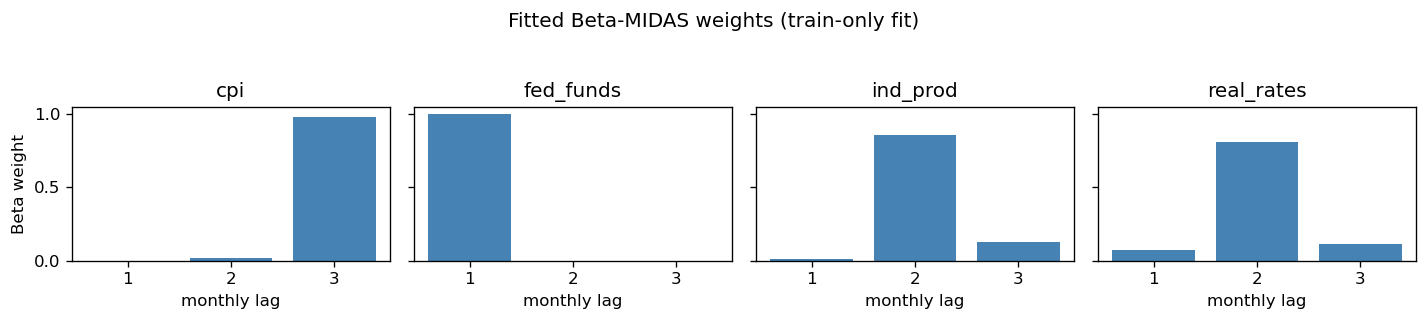

In [6]:
fig, axes = plt.subplots(1, N_VARS, figsize=(3*N_VARS, 2.5), sharey=True)
if N_VARS == 1: axes = [axes]
for ax, v in zip(axes, MACRO_VARS):
    ax.bar(K_ARR, weights[v], color='steelblue')
    ax.set_title(v); ax.set_xticks(K_ARR); ax.set_xlabel('monthly lag')
axes[0].set_ylabel('Beta weight')
fig.suptitle('Fitted Beta-MIDAS weights (train-only fit)', y=1.05)
plt.tight_layout(); plt.show()


## 4. LSTM architecture + sequence builder

Identical to `06_lstm.ipynb` — single LSTM layer + linear head, MSE loss, Adam, gradient
clipping, early stopping on val loss. Feature scaling per variant via `StandardScaler` fit
on train only.


In [7]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def make_sequences(data, seq_len, target_col, horizon=1):
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


## 5. Hyperparameter tuning on `LSTM-EXOG` (no MIDAS, no sentiment)

Same protocol as `06_lstm.ipynb` — small grid, tuned once on the baseline variant, reused
across all variants. Per-variant tuning would 8× the runtime with little gain since only
the input dimension changes.


In [8]:
SEQ_GRID     = [10, 20]
HIDDEN_GRID  = [16, 32]
DROPOUT_GRID = [0.1, 0.2, 0.3]
tune_cols = [TARGET] + [c for c in EXOG if c in train.columns]

def eval_config(seq_len, hidden, dropout):
    scaler_t   = StandardScaler().fit(train[tune_cols].fillna(0))
    tr_s       = scaler_t.transform(train[tune_cols].fillna(0))
    va_s       = scaler_t.transform(val[tune_cols].fillna(0))
    target_idx = tune_cols.index(TARGET)
    X_tr, y_tr = make_sequences(tr_s, seq_len, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s, seq_len, target_idx, HORIZON)
    if len(X_tr) == 0 or len(X_va) == 0: return np.inf
    tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1)), batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va).unsqueeze(1)), batch_size=BATCH, shuffle=False)
    model = LSTMForecaster(len(tune_cols), hidden, N_LAYERS, dropout).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR); crit = nn.MSELoss()
    best_vl, pat = np.inf, 0
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item() for xb, yb in va_loader])
        if vl < best_vl: best_vl, pat = vl, 0
        else:
            pat += 1
            if pat >= PATIENCE: break
    return best_vl

configs = list(product(SEQ_GRID, HIDDEN_GRID, DROPOUT_GRID))
print(f'Tuning on LSTM-EXOG — {len(configs)} configs')
print('-' * 60)
search = []
for seq_len, hidden, dropout in configs:
    vl = eval_config(seq_len, hidden, dropout)
    print(f'  SEQ_LEN={seq_len:>3}  HIDDEN={hidden:>3}  DROPOUT={dropout}  val_loss={vl:.6f}')
    search.append({'seq_len': seq_len, 'hidden': hidden, 'dropout': dropout, 'val_loss': vl})
best = min(search, key=lambda r: r['val_loss'])
print(f'\nBest:  SEQ_LEN={best["seq_len"]}  HIDDEN={best["hidden"]}  DROPOUT={best["dropout"]}  val_loss={best["val_loss"]:.6f}')
SEQ_LEN, HIDDEN, DROPOUT = best['seq_len'], best['hidden'], best['dropout']


Tuning on LSTM-EXOG — 12 configs
------------------------------------------------------------


  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.1  val_loss=1.384054


  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.2  val_loss=1.408274


  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.3  val_loss=1.367145


  SEQ_LEN= 10  HIDDEN= 32  DROPOUT=0.1  val_loss=1.436820


...

  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.2  val_loss=1.572845


  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.3  val_loss=1.562595


  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.1  val_loss=1.509120


  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.2  val_loss=1.524490


  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.3  val_loss=1.517482

Best:  SEQ_LEN=10  HIDDEN=16  DROPOUT=0.3  val_loss=1.367145


## 6. Variants

Three variants, baseline = `LSTM-EXOG`. The new variants add the **MIDAS-imputed weekly
macro composites** as additional features.


In [9]:
MARKET_FEATURES = [TARGET] + [c for c in EXOG if c in train.columns]

variants = {
    'LSTM-EXOG':                       MARKET_FEATURES,
    'LSTM-EXOG-MACROMIDAS':            MARKET_FEATURES + MIDAS_COLS,
    'LSTM-EXOG-MACROMIDAS-SENTIMENT':  MARKET_FEATURES + MIDAS_COLS + ['reddit_sentiment','news_sentiment'],
}

def run_variant(name, feature_cols):
    print(f'\n{"=" * 50}\nVariant: {name}\n{"=" * 50}')
    cols       = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    scaler = StandardScaler().fit(train[cols].fillna(0))
    tr_s   = scaler.transform(train[cols].fillna(0))
    va_s   = scaler.transform(val[cols].fillna(0))
    te_s   = scaler.transform(test[cols].fillna(0))

    X_tr, y_tr = make_sequences(tr_s, SEQ_LEN, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s, SEQ_LEN, target_idx, HORIZON)
    X_te, y_te = make_sequences(te_s, SEQ_LEN, target_idx, HORIZON)
    dates      = test.index[SEQ_LEN:len(test) - HORIZON + 1]

    print(f'  Train seqs: {len(X_tr)}  Val seqs: {len(X_va)}  Test seqs: {len(X_te)}')

    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_tr, y_tr)
    val_loader   = to_loader(X_va, y_va, shuffle=False)

    ckpt  = f'../../data/processed/lstm_imputer_{name.lower().replace("+","_").replace("-","_")}_weekly_best.pt'
    model = LSTMForecaster(len(cols), HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

    best_val, pat_cnt = np.inf, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item() for xb, yb in val_loader])
        sched.step(vl)
        if epoch % 25 == 0: print(f'  Epoch {epoch:3d}  val={vl:.6f}')
        if vl < best_val:
            best_val, pat_cnt = vl, 0
            torch.save(model.state_dict(), ckpt)
        else:
            pat_cnt += 1
            if pat_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}'); break

    model.load_state_dict(torch.load(ckpt)); model.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        test_loader = to_loader(X_te, y_te, shuffle=False)
        for xb, yb in test_loader:
            preds_s.extend(model(xb.to(DEVICE)).cpu().numpy().flatten())
            acts_s.extend(yb.numpy().flatten())

    mu, sigma  = scaler.mean_[target_idx], scaler.scale_[target_idx]
    preds      = np.array(preds_s) * sigma + HORIZON * mu
    actuals    = np.array(acts_s)  * sigma + HORIZON * mu

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds))) / np.sum(np.abs(actuals))
    print(f'  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}, preds, actuals, dates

results, all_preds = {}, {}
actuals_arr = dates_arr = None
for name, cols in variants.items():
    m, preds, acts, dates = run_variant(name, cols)
    results[name] = m; all_preds[name] = preds
    actuals_arr, dates_arr = acts, dates



Variant: LSTM-EXOG
  Train seqs: 355  Val seqs: 42  Test seqs: 165


  Early stopping at epoch 16
  RMSE=0.053133  MAE=0.038011  DA=0.545  WDA=0.562

Variant: LSTM-EXOG-MACROMIDAS
  Train seqs: 355  Val seqs: 42  Test seqs: 165


  Early stopping at epoch 16
  RMSE=0.052826  MAE=0.037926  DA=0.576  WDA=0.599

Variant: LSTM-EXOG-MACROMIDAS-SENTIMENT
  Train seqs: 355  Val seqs: 42  Test seqs: 165


  Early stopping at epoch 17
  RMSE=0.052793  MAE=0.038026  DA=0.509  WDA=0.575


## 7. Results — naïve baseline + metrics table

In [10]:
naive_pred = np.concatenate([[np.nan], actuals_arr[:-1]])
mask = ~np.isnan(naive_pred)
n_acts, n_preds = actuals_arr[mask], naive_pred[mask]
naive_row = {
    'model':   'Naive (t-1 week)',
    'rmse':    float(np.sqrt(mean_squared_error(n_acts, n_preds))),
    'mae':     float(mean_absolute_error(n_acts, n_preds)),
    'dir_acc': float(np.mean(np.sign(n_acts) == np.sign(n_preds))),
    'wda':     float(np.sum(np.abs(n_acts) * (np.sign(n_acts) == np.sign(n_preds))) / np.sum(np.abs(n_acts))),
}

metrics_df = pd.DataFrame([naive_row] + list(results.values()))
metrics_df.to_csv('../../data/processed/metrics_lstm_imputer_weekly.csv', index=False)

print(f'{"Model":<40}  {"RMSE":>10}  {"MAE":>10}  {"DA":>6}  {"WDA":>6}')
print('-' * 78)
for _, row in metrics_df.iterrows():
    print(f'{row["model"]:<40}  {row["rmse"]:>10.6f}  {row["mae"]:>10.6f}  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}')


Model                                           RMSE         MAE      DA     WDA
------------------------------------------------------------------------------
Naive (t-1 week)                            0.077064    0.054751   0.494   0.494
LSTM-EXOG                                   0.053133    0.038011   0.545   0.562
LSTM-EXOG-MACROMIDAS                        0.052826    0.037926   0.576   0.599
LSTM-EXOG-MACROMIDAS-SENTIMENT              0.052793    0.038026   0.509   0.575


## 8. Sub-period breakdown — best variant by WDA

Same `PERIODS` buckets as every other weekly notebook.


In [11]:
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import period_metrics, diebold_mariano, PERIODS

best_name = max(results, key=lambda k: results[k]['wda'])
best_pred = all_preds[best_name]
print('Best variant by WDA:', best_name)

res = period_metrics(actuals_arr, best_pred, dates_arr, PERIODS)
display(res[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.35, vmax=0.65))
res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_lstm_imputer_weekly.csv')


Best variant by WDA: LSTM-EXOG-MACROMIDAS


,n,DA,WDA
Period,,,
2023 (choppy),42,0.548,0.546
2024 (bull start),52,0.500,0.570
2025 (bull run),52,0.673,0.730
2026 (YTD),19,0.579,0.513
── Full test ──,165,0.576,0.599


## 9. Diebold-Mariano vs `LSTM-EXOG`

Does adding MIDAS-imputed macro composites yield significantly better squared-error
forecasts than the EXOG-only LSTM?


In [12]:
print('Diebold-Mariano tests — each variant vs LSTM-EXOG baseline')
print('H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant')
print('-' * 90)
baseline_key  = 'LSTM-EXOG'
baseline_pred = all_preds[baseline_key]
for name, pred in all_preds.items():
    if name == baseline_key: continue
    diebold_mariano(actuals_arr, baseline_pred, pred, baseline_key, name)


Diebold-Mariano tests — each variant vs LSTM-EXOG baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
LSTM-EXOG                                vs LSTM-EXOG-MACROMIDAS                      DM=+1.097  p=0.273  (ns)
LSTM-EXOG                                vs LSTM-EXOG-MACROMIDAS-SENTIMENT            DM=+1.128  p=0.259  (ns)


## 10. 2026 zoom — actual vs best variant

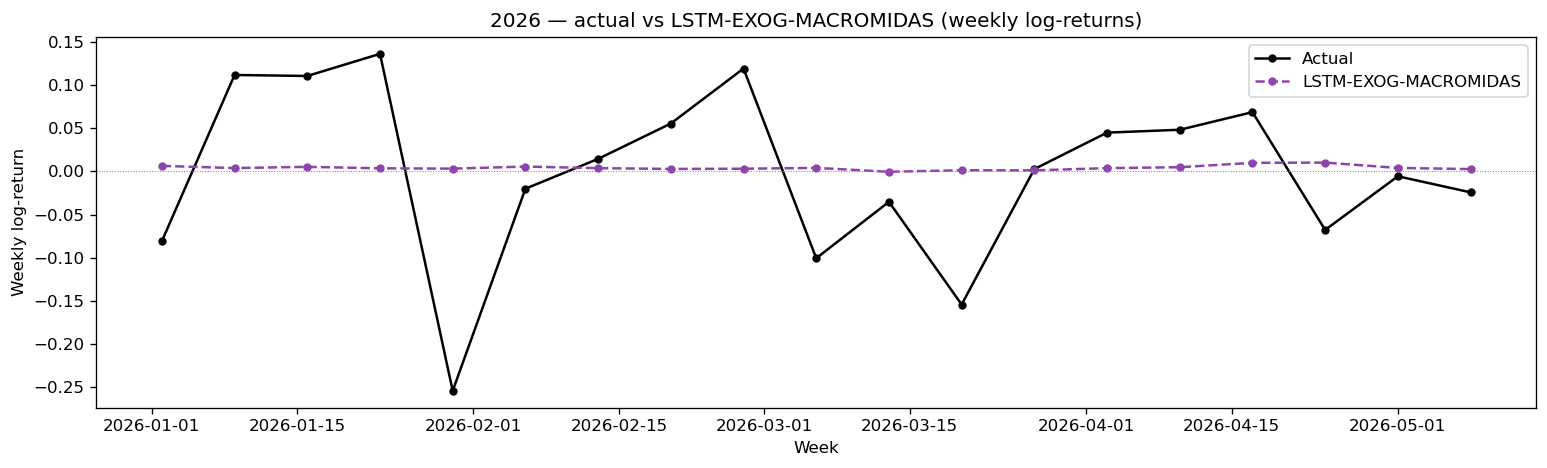

In [13]:
df26 = pd.DataFrame({'actual': actuals_arr, 'pred': best_pred},
                     index=pd.DatetimeIndex(dates_arr))
df26 = df26.loc['2026':]

if df26.empty:
    print('No 2026 data in test set yet.')
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26['actual'], color='black',  lw=1.5, marker='o', ms=4, label='Actual')
    ax.plot(df26.index, df26['pred'],   color='#8e44ad', lw=1.5, marker='o', ms=4, ls='--', label=best_name)
    ax.axhline(0, color='grey', lw=0.6, ls=':')
    ax.set_title(f'2026 — actual vs {best_name} (weekly log-returns)', fontsize=12)
    ax.set_ylabel('Weekly log-return'); ax.set_xlabel('Week'); ax.legend()
    plt.tight_layout(); plt.show()


## 11. Discussion

The interesting question this notebook answers — beyond the headline metrics — is **what
MIDAS extracts from monthly macro that pure forward-filling would lose**:

- The fitted Beta weights (§3 viz) show the time-decay profile per macro variable. Sharp
  weight on lag-1 = recent release dominates. Flatter = longer memory matters.
- The composites $m_{v,t}$ are smooth weekly series that change *every* week (not just on
  release dates), reflecting the gradually-decaying influence of recent releases.

Compare this notebook's `LSTM-EXOG-MACROMIDAS` row to `06_lstm.ipynb`'s `LSTM-EXOG` row:

- If DM is significant → MIDAS imputation is a genuine value-add and the hybrid story is
  defensible: "MIDAS handles frequency mismatch, LSTM handles nonlinear dynamics."
- If DM is not significant → consistent with the broader finding that weekly silver
  returns are nearly white noise (cf. `02_var.ipynb` Granger results, `01_eda.ipynb`
  ACF/Ljung-Box). The MIDAS composites add a real signal, but the *target* doesn't have
  enough predictability for any feature engineering to materially help.

Either outcome is a defensible TFM finding. The methodology is the contribution.
